In [ ]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo  
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, cluster, silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn import datasets
sns.set_style("whitegrid")
sns.color_palette("tab10")
scaler = StandardScaler()

# Funkcje pomocnicze

In [3]:
def plot_metrics(metrics_df, variable):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    sns.scatterplot(data=metrics_df, x=variable, y='rand_index', ax=axes[0, 0])
    sns.scatterplot(data=metrics_df, x=variable, y='purity', ax=axes[0, 1])
    sns.scatterplot(data=metrics_df, x=variable, y='silhouette_avg', ax=axes[1, 0])
    sns.scatterplot(data=metrics_df, x=variable, y='db_index', ax=axes[1, 1])
    axes[0, 0].set_title('Adjusted Rand Index vs ' + variable)
    axes[0, 1].set_title('Purity vs ' + variable)
    axes[1, 0].set_title('Silhouette Score vs ' + variable)
    axes[1, 1].set_title('Davies-Bouldin Index vs ' + variable)
    for ax in axes.flat:
        ax.set_xlabel(variable)
        ax.set_ylabel('Score')
        ax.grid(True)
    plt.tight_layout()
    plt.show()

In [4]:
def plot_metrics_dbscan(metrics_euclidean, metrics_manhatan, metrics_cosine, variable):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    sns.scatterplot(data=metrics_euclidean, x=variable, y='rand_index', ax=axes[0, 0])
    sns.scatterplot(data=metrics_euclidean, x=variable, y='purity', ax=axes[0, 1])
    sns.scatterplot(data=metrics_euclidean, x=variable, y='silhouette_avg', ax=axes[1, 0])
    sns.scatterplot(data=metrics_euclidean, x=variable, y='db_index', ax=axes[1, 1])
    sns.scatterplot(data=metrics_manhatan, x=variable, y='rand_index', ax=axes[0, 0], color='orange')
    sns.scatterplot(data=metrics_manhatan, x=variable, y='purity', ax=axes[0, 1], color='orange')
    sns.scatterplot(data=metrics_manhatan, x=variable, y='silhouette_avg', ax=axes[1, 0], color='orange')
    sns.scatterplot(data=metrics_manhatan, x=variable, y='db_index', ax=axes[1, 1], color='orange')
    sns.scatterplot(data=metrics_cosine, x=variable, y='rand_index', ax=axes[0, 0], color='green', alpha=0.5)
    sns.scatterplot(data=metrics_cosine, x=variable, y='purity', ax=axes[0, 1], color='green', alpha=0.5)
    sns.scatterplot(data=metrics_cosine, x=variable, y='silhouette_avg', ax=axes[1, 0], color='green', alpha=0.5)
    sns.scatterplot(data=metrics_cosine, x=variable, y='db_index', ax=axes[1, 1], color='green', alpha=0.5)
    axes[0, 0].set_title('Adjusted Rand Index vs ' + variable)
    axes[0, 1].set_title('Purity vs ' + variable)
    axes[1, 0].set_title('Silhouette Score vs ' + variable)
    axes[1, 1].set_title('Davies-Bouldin Index vs ' + variable)
    for ax in axes.flat:
        ax.set_xlabel(variable)
        ax.set_ylabel('Score')
        ax.grid(True)
    plt.tight_layout()
    fig.legend(['Euclidean', 'Manhattan', 'Cosine'], loc='upper right')
    plt.show()

In [5]:
def calculate_metrics_labels(y_true, y_pred):
    rand_index = adjusted_rand_score(y_true, y_pred)
    contingency_matrix = cluster.contingency_matrix(y_true, y_pred)
    purity = np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)
    return rand_index, purity

In [6]:
def calculate_metrics_shilhouette(X, y_pred):
    n_clusters = len(set(y_pred)) - (1 if -1 in y_pred else 0)
    if n_clusters < 2:
        return None, None
    else:
        return silhouette_score(X, y_pred), davies_bouldin_score(X, y_pred)

In [7]:
def clustering_kmeans(X_train, y_true, variable, min, max, step, n_clusters=3, n_init=10, max_iter=300, init='k-means++'):
    metrics = []
    
    for i in range(min, max, step):
        if variable == 'n_clusters':
            kmeans = KMeans(n_clusters=i, n_init=n_init, max_iter=max_iter, init=init).fit_predict(X_train)
        elif variable == 'n_init':
            kmeans = KMeans(n_clusters=n_clusters, n_init=i, max_iter=max_iter, init=init).fit_predict(X_train)
        elif variable == 'max_iter':
            kmeans = KMeans(n_clusters=n_clusters, n_init=n_init, max_iter=i, init=init).fit_predict(X_train)

        rand_index, purity = calculate_metrics_labels(y_true, kmeans)
        silhouette_avg, db_index = calculate_metrics_shilhouette(X_train, kmeans)
        metrics.append({
            'n_clusters': i if variable == 'n_clusters' else n_clusters,
            'n_init': i if variable == 'n_init' else n_init,
            'max_iter': i if variable == 'max_iter' else max_iter,
            'rand_index': rand_index,
            'purity': purity,
            'silhouette_avg': silhouette_avg,
            'db_index': db_index
        })
    return pd.DataFrame(metrics)

In [8]:
def clustering_dbscan(X_train, y_true, variable, min_val, max_val, step,
                      eps_value=0.5, min_samples_value=5, metrics_name='euclidean'):
    metrics = []

    if variable == 'eps':
        values = np.arange(min_val, max_val, step)
        for eps in values:
            labels = DBSCAN(eps=eps, min_samples=min_samples_value, metric=metrics_name).fit_predict(X_train)
            rand_index, purity = calculate_metrics_labels(y_true, labels)
            silhouette_avg, db_index = calculate_metrics_shilhouette(X_train, labels)
            metrics.append({
                'eps': eps,
                'min_samples': min_samples_value,
                'metric': metrics_name,
                'rand_index': rand_index,
                'purity': purity,
                'silhouette_avg': silhouette_avg,
                'db_index': db_index
            })

    elif variable == 'min_samples':
        values = range(min_val, max_val, step)
        for min_s in values:
            labels = DBSCAN(eps=eps_value, min_samples=min_s, metric=metrics_name).fit_predict(X_train)
            rand_index, purity = calculate_metrics_labels(y_true, labels)
            silhouette_avg, db_index = calculate_metrics_shilhouette(X_train, labels)
            metrics.append({
                'eps': eps_value,
                'min_samples': min_s,
                'metric': metrics_name,
                'rand_index': rand_index,
                'purity': purity,
                'silhouette_avg': silhouette_avg,
                'db_index': db_index
            })

    elif variable == 'metric':
        for metric in metrics_name:
            labels = DBSCAN(eps=eps_value, min_samples=min_samples_value, metric=metrics_name).fit_predict(X_train)
            rand_index, purity = calculate_metrics_labels(y_true, labels)
            silhouette_avg, db_index = calculate_metrics_shilhouette(X_train, labels)
            metrics.append({
                'eps': eps_value,
                'min_samples': min_samples_value,
                'metric': metrics_name,
                'rand_index': rand_index,
                'purity': purity,
                'silhouette_avg': silhouette_avg,
                'db_index': db_index
            })

    return pd.DataFrame(metrics)


# Iris - sanity check

## KMeans (iris)

In [9]:
iris = datasets.load_iris()
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
X_iris = scaler.fit_transform(df_iris.drop('target', axis=1))

In [10]:
kmeans = KMeans(n_clusters=3)
kmeans.fit_predict(X_iris)
df_iris['kmeans_cluster'] = kmeans.labels_

In [11]:
rand_index, purity = calculate_metrics_labels(df_iris['target'], df_iris['kmeans_cluster'])
print(f'KMeans clustering - (adjusted) Rand Index: {rand_index:.4f}, Purity: {purity:.4f}')
silhouette_avg, db_index = calculate_metrics_shilhouette(X_iris, df_iris['kmeans_cluster'])
print(f'Silhouette Score: {silhouette_avg:.4f}, Davies-Bouldin Index: {db_index:.4f}')

KMeans clustering - (adjusted) Rand Index: 0.6201, Purity: 0.8333
Silhouette Score: 0.4599, Davies-Bouldin Index: 0.8336


In [12]:
iris_metrics = clustering_kmeans(X_iris, df_iris['target'], 'n_clusters', 1, len(df_iris), 1)

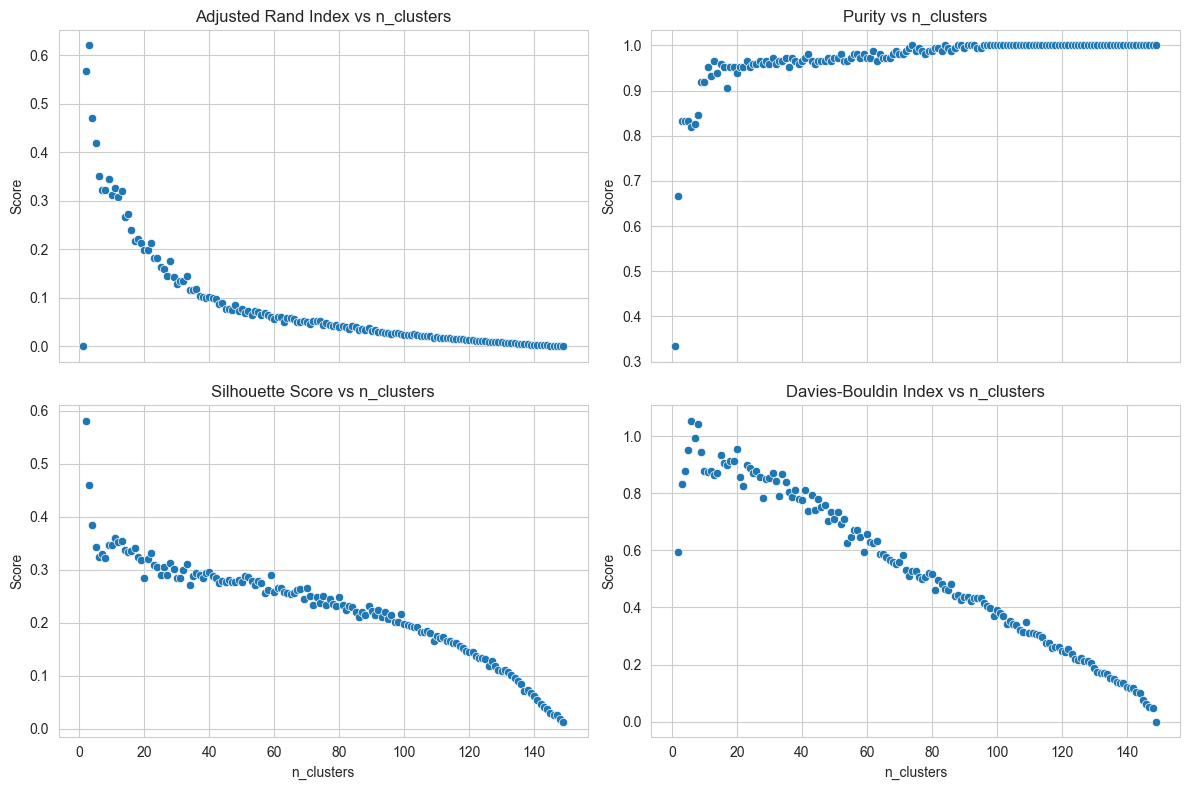

In [13]:
plot_metrics(iris_metrics, 'n_clusters')

## DBSCAN (iris)

In [14]:
dbscan_iris = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_iris)
df_iris['dbscan_cluster'] = dbscan_iris

In [15]:
rand_index, purity = calculate_metrics_labels(df_iris['target'], df_iris['dbscan_cluster'])
print(f'DBSCAN clustering - (adjusted) Rand Index: {rand_index:.4f}, Purity: {purity:.4f}')
silhouette_avg, db_index = calculate_metrics_shilhouette(X_iris, df_iris['dbscan_cluster'])
print(f'Silhouette Score: {silhouette_avg:.4f}, Davies-Bouldin Index: {db_index:.4f}')

DBSCAN clustering - (adjusted) Rand Index: 0.4421, Purity: 0.6800
Silhouette Score: 0.3565, Davies-Bouldin Index: 7.1241


In [16]:
dbscan_metrics = clustering_dbscan(X_iris, df_iris['target'], 'eps', 0.1, 3, 0.01)

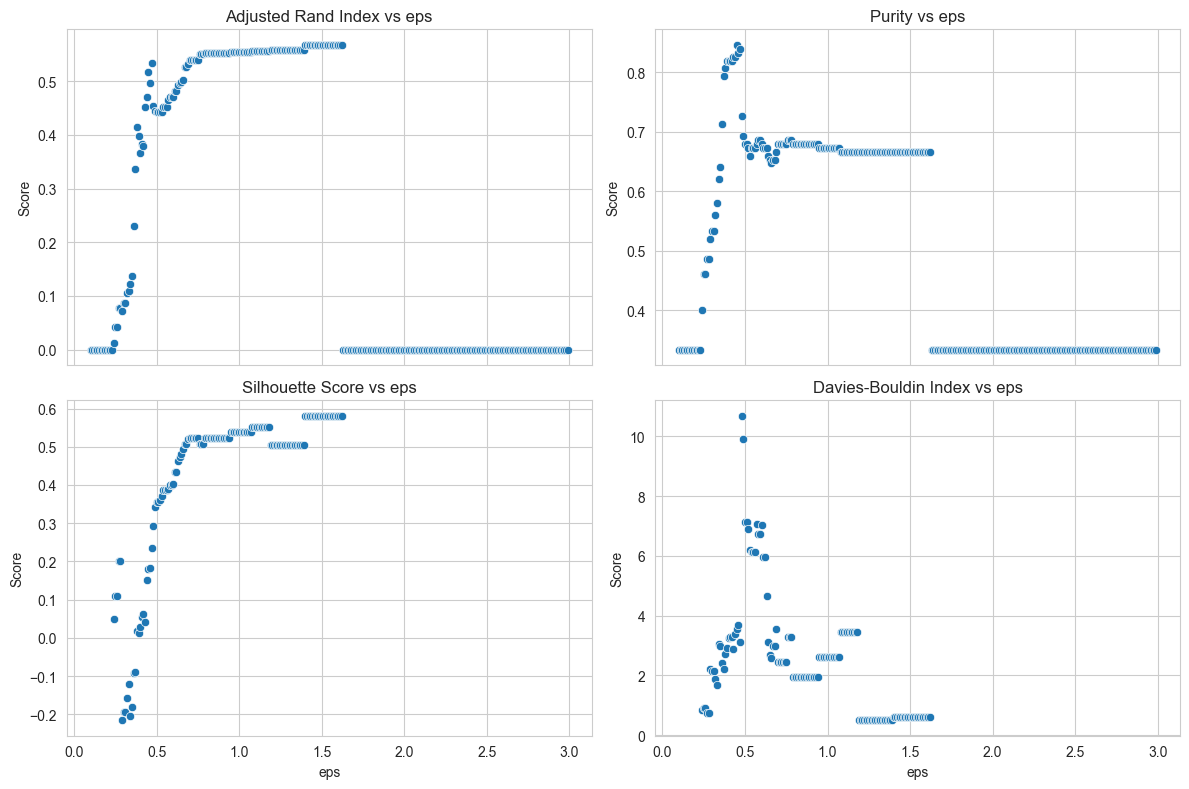

In [17]:
plot_metrics(dbscan_metrics, 'eps')

## Porównanie

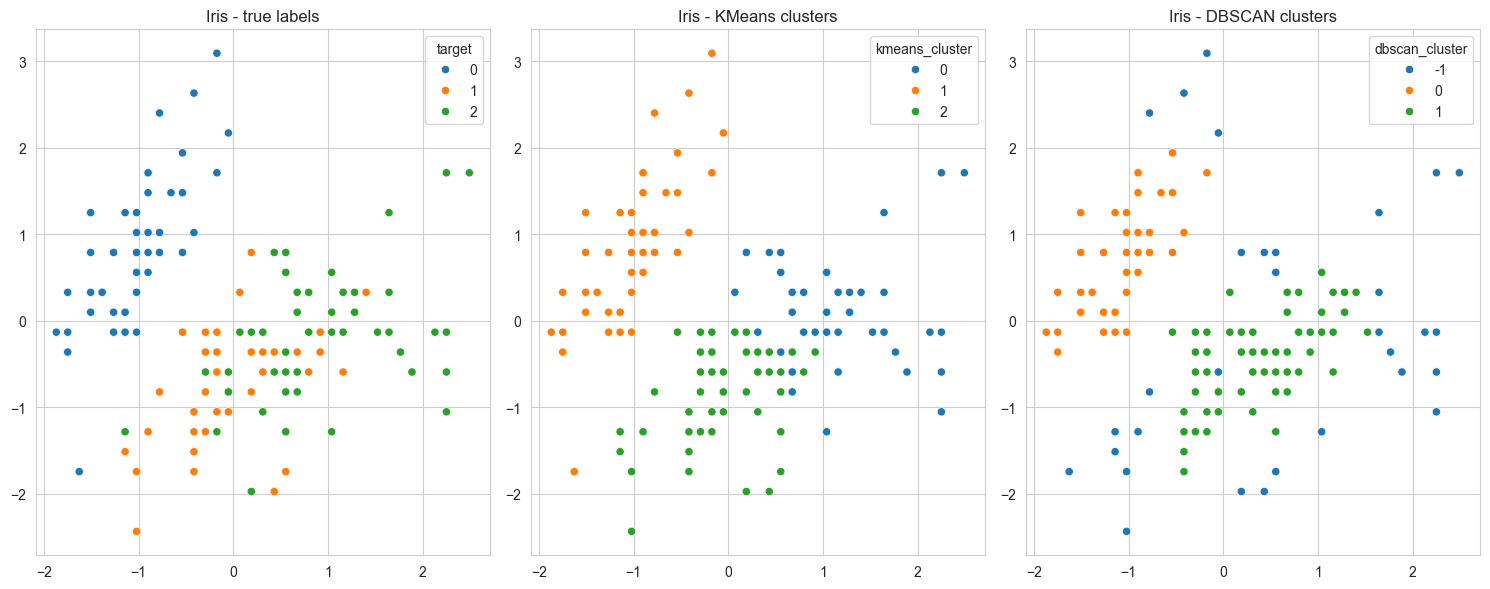

In [18]:
fig, ax = plt.subplots(figsize=(15, 6), nrows=1, ncols=3)
sns.scatterplot(x=X_iris[:, 0], y=X_iris[:, 1], hue=df_iris['target'], ax=ax[0], palette='tab10')
sns.scatterplot(x=X_iris[:, 0], y=X_iris[:, 1], hue=df_iris['kmeans_cluster'], ax=ax[1], palette='tab10')
sns.scatterplot(x=X_iris[:, 0], y=X_iris[:, 1], hue=df_iris['dbscan_cluster'], ax=ax[2], palette='tab10')
ax[0].set_title('Iris - true labels')
ax[1].set_title('Iris - KMeans clusters')
ax[2].set_title('Iris - DBSCAN clusters')
plt.tight_layout()
plt.show()

# KMeans

## Seeds

In [19]:
seeds_df = pd.read_csv('seeds_dataset.txt', sep='\s+', header=None)
seeds_df = seeds_df.rename(columns={0: 'area', 1: 'perimeter', 2: 'compactness',
                                    3: 'length_of_kernel', 4: 'width_of_kernel',
                                    5: 'asymmetry_coefficient', 6: 'length_of_kernel_groove', 7: 'class'})
seeds_df

,area,perimeter,compactness,length_of_kernel,width_of_kernel,asymmetry_coefficient,length_of_kernel_groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


In [20]:
X_seeds = scaler.fit_transform(seeds_df.drop('class', axis=1))
metrics_seeds_n_clusters = clustering_kmeans(
    X_seeds,
    seeds_df['class'],
    variable='n_clusters',
    min=1,
    max=len(seeds_df),
    step=1)

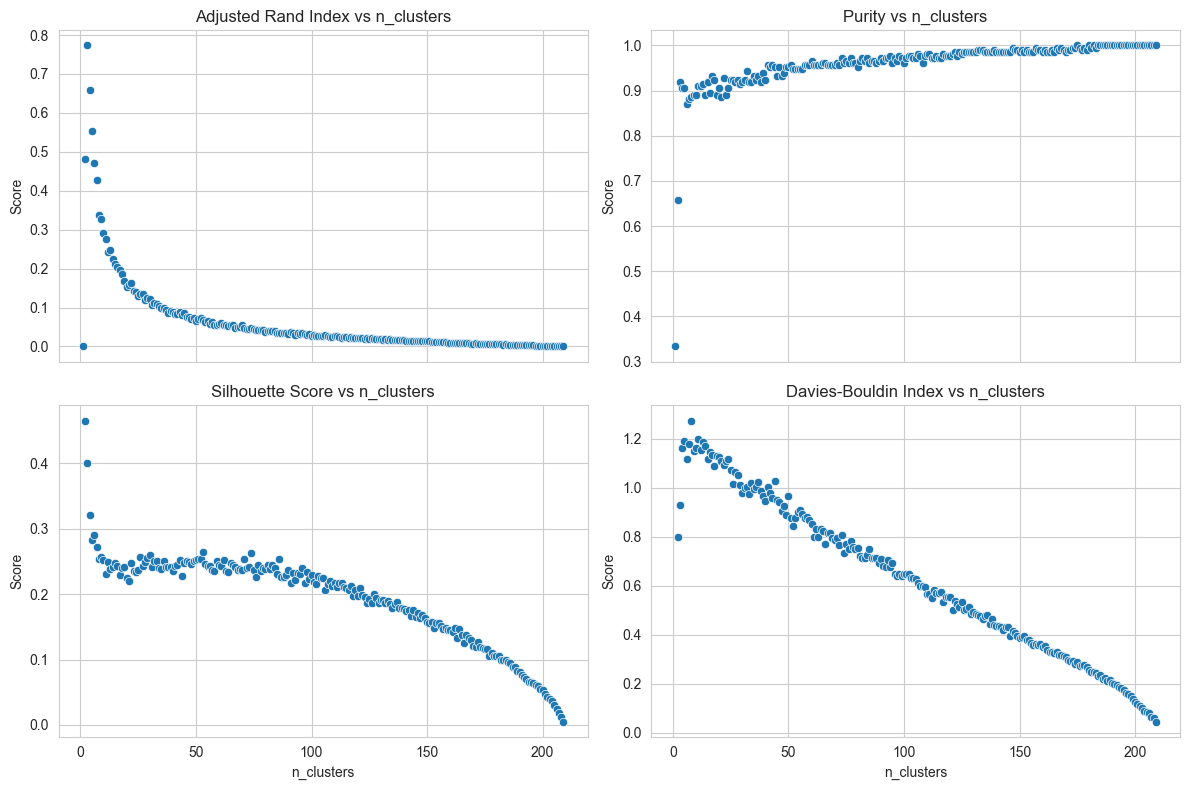

In [12]:
plot_metrics(metrics_seeds_n_clusters, 'n_clusters')

- Unsupervised:

(a) Silhouette: jak dobrze punkt pasuje do swojego klastra (liczy średnią odległość punkt $i$ do wszystkich innych punktów w tym samym klastrze (spójność, im mniejsza, tym lepiej) oraz średnią odległość punktu $i$ do wszystkich punktów w najbliższym klastrze (separacja, im większa, tym lepiej)) vs. innych klastrów. Od -1 do 1. 1 - dobrze dopasowany, 0 - na granicy klastrów, -1 punkt został przypisany do niewłaściwego klastra.

(b) Davies-Bouldin Index: relacja między rozrzutem klastrów a ich oddzieleniem – im niższy, tym lepiej. Zakres od 0 do $\infty$, gdzie 0 oznacza idealne klastry (brak rozrzutu i maksymalne oddzielenie).

- Supervised:

(a) Rand Index: zgodność par punktów (czy są razem/oddzielnie w klastrach i klasach), od 0 (brak zgodności) do 1 (pełna zgodność). (adjusted od -1, gorzej niz losowo)

(b) Purity: udział dominującej klasy w klastrze – im wyższy, tym lepiej, od 0 (klastry kompletnie losowe względem klas) do 1 (klastry czyste, wszystkie punkty w klastrze należą do tej samej klasy).


In [13]:
metrics_seeds_n_init = clustering_kmeans(
    X_seeds,
    seeds_df['class'],
    variable='n_init',
    min=2,
    max=100,
    step=1,
    n_clusters=3,
    init='random')

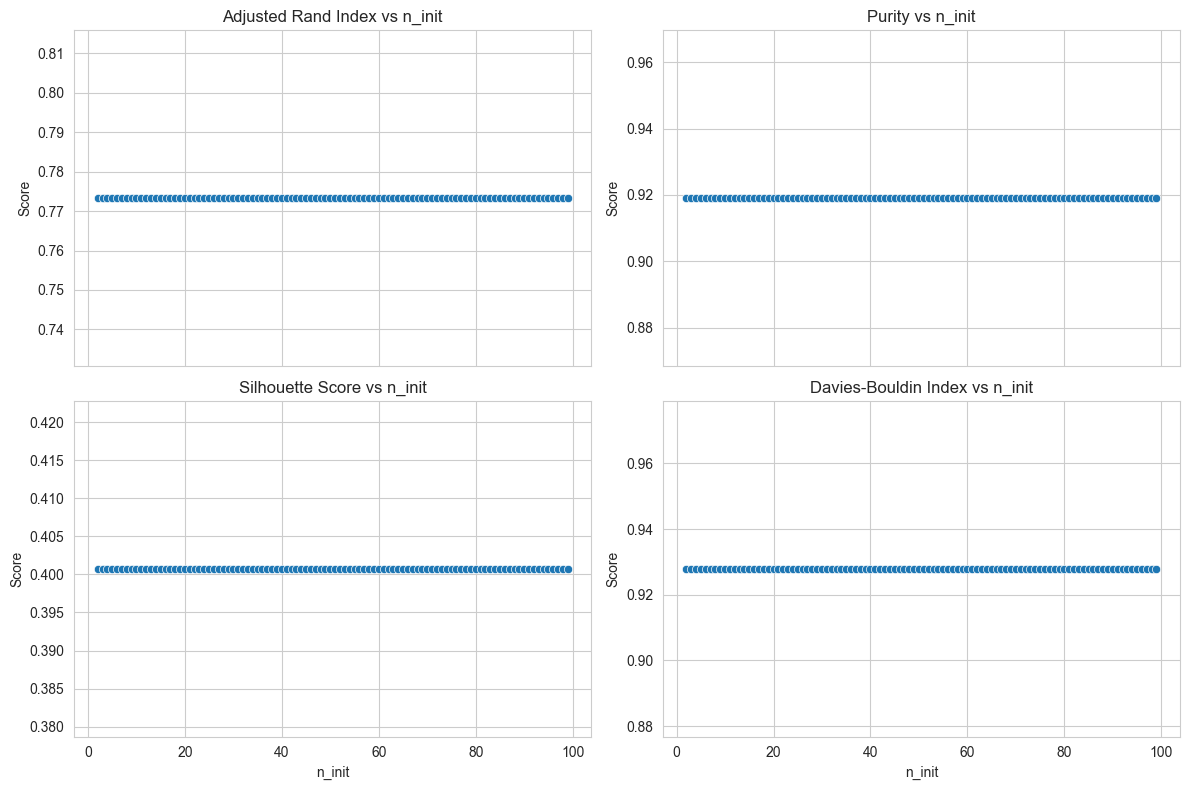

In [14]:
plot_metrics(metrics_seeds_n_init, 'n_init')

In [15]:
metric_seeds_max_iter = clustering_kmeans(
    X_seeds,
    seeds_df['class'],
    variable='max_iter',
    min=1,
    max=360,
    step=10,
    n_clusters=3,
    n_init=10)

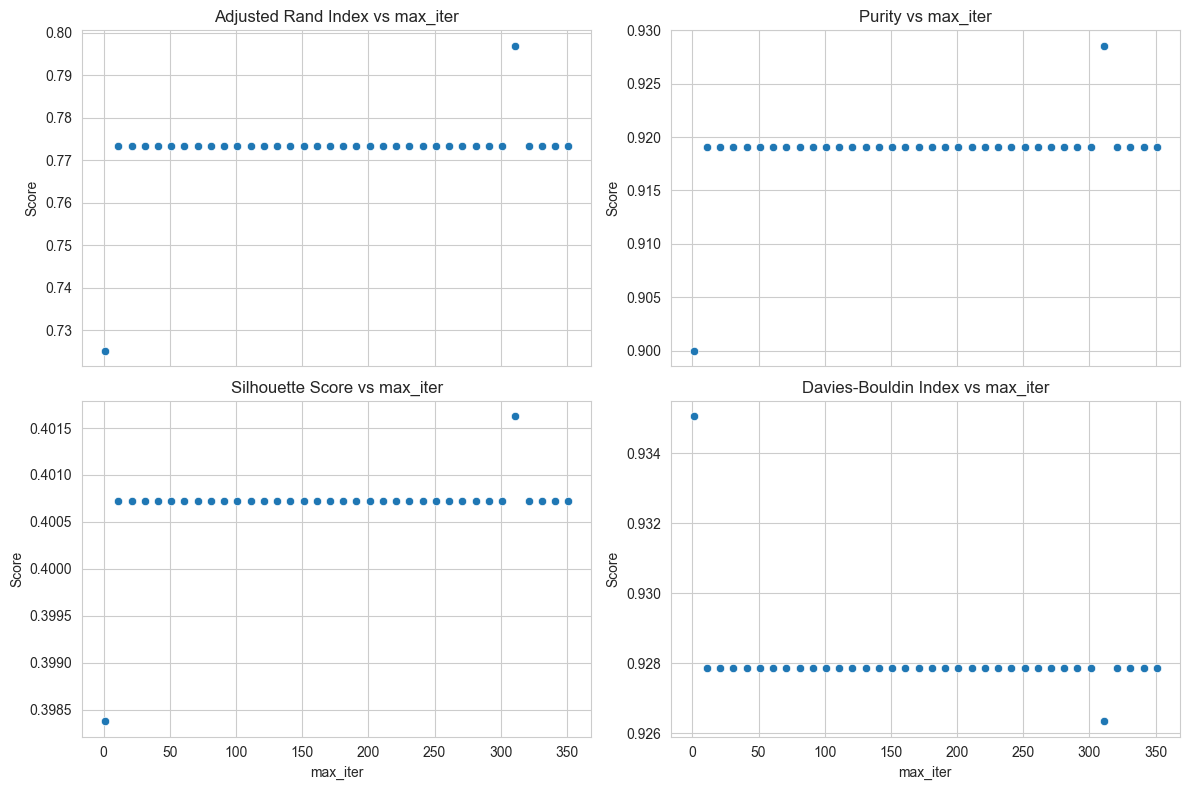

In [16]:
plot_metrics(metric_seeds_max_iter, 'max_iter')

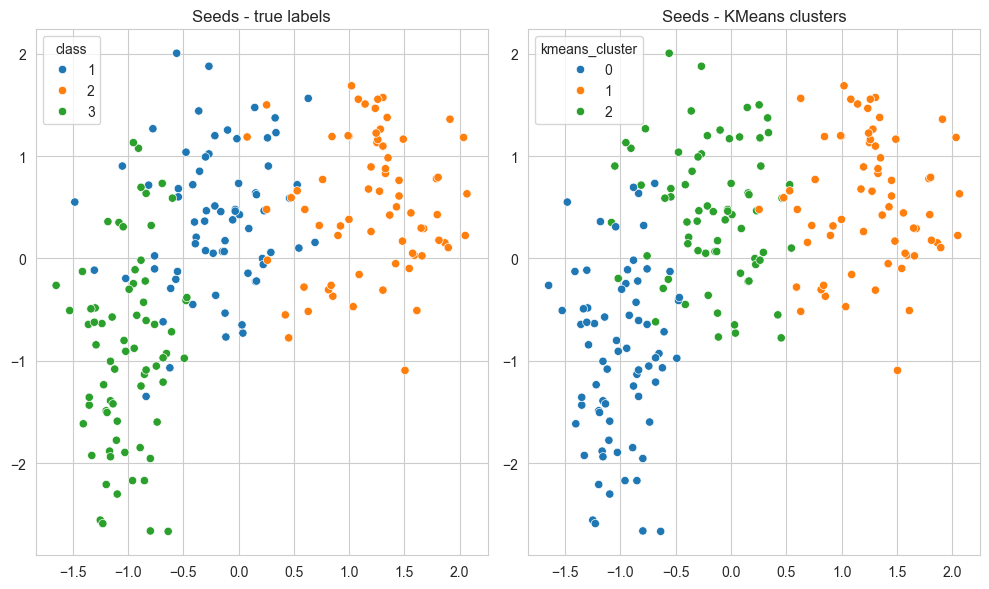

In [21]:
kmeans_seeds = KMeans(n_clusters=3, n_init=10, max_iter=300)
kmeans_seeds.fit_predict(X_seeds)
seeds_df['kmeans_cluster'] = kmeans_seeds.labels_
fig, ax = plt.subplots(figsize=(10, 6), nrows=1, ncols=2)
sns.scatterplot(x=X_seeds[:, 1], y=X_seeds[:, 2], hue=seeds_df['class'], ax=ax[0], palette='tab10')
sns.scatterplot(x=X_seeds[:, 1], y=X_seeds[:, 2], hue=seeds_df['kmeans_cluster'], ax=ax[1], palette='tab10')
ax[0].set_title('Seeds - true labels')
ax[1].set_title('Seeds - KMeans clusters')
plt.tight_layout()
plt.show()

In [18]:
rand_index, purity = calculate_metrics_labels(seeds_df['class'], seeds_df['kmeans_cluster'])
print(f'KMeans clustering - (adjusted) Rand Index: {rand_index:.4f}, Purity: {purity:.4f}')
calculate_metrics_shilhouette(seeds_df.drop(columns='class'), seeds_df['kmeans_cluster'])
silhouette_avg, db_index = calculate_metrics_shilhouette(seeds_df.drop(columns='class'), seeds_df['kmeans_cluster'])
print(f'Silhouette Score: {silhouette_avg:.4f}, Davies-Bouldin Index: {db_index:.4f}')

KMeans clustering - (adjusted) Rand Index: 0.7733, Purity: 0.9190
Silhouette Score: 0.4893, Davies-Bouldin Index: 0.7367


## Glass

In [23]:
glass_identification = fetch_ucirepo(id=42)
X_glass = glass_identification.data.features
y_glass = glass_identification.data.targets
df_glass = pd.concat([X_glass, y_glass], axis=1)
df_glass

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type_of_glass
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [24]:
X_glass = scaler.fit_transform(df_glass.drop(columns='Type_of_glass'))
metrics_glass_n_clusters = clustering_kmeans(
    X_glass,
    df_glass['Type_of_glass'],
    variable='n_clusters',
    min=1,
    max=len(df_glass),
    step=1,
    n_init=10)

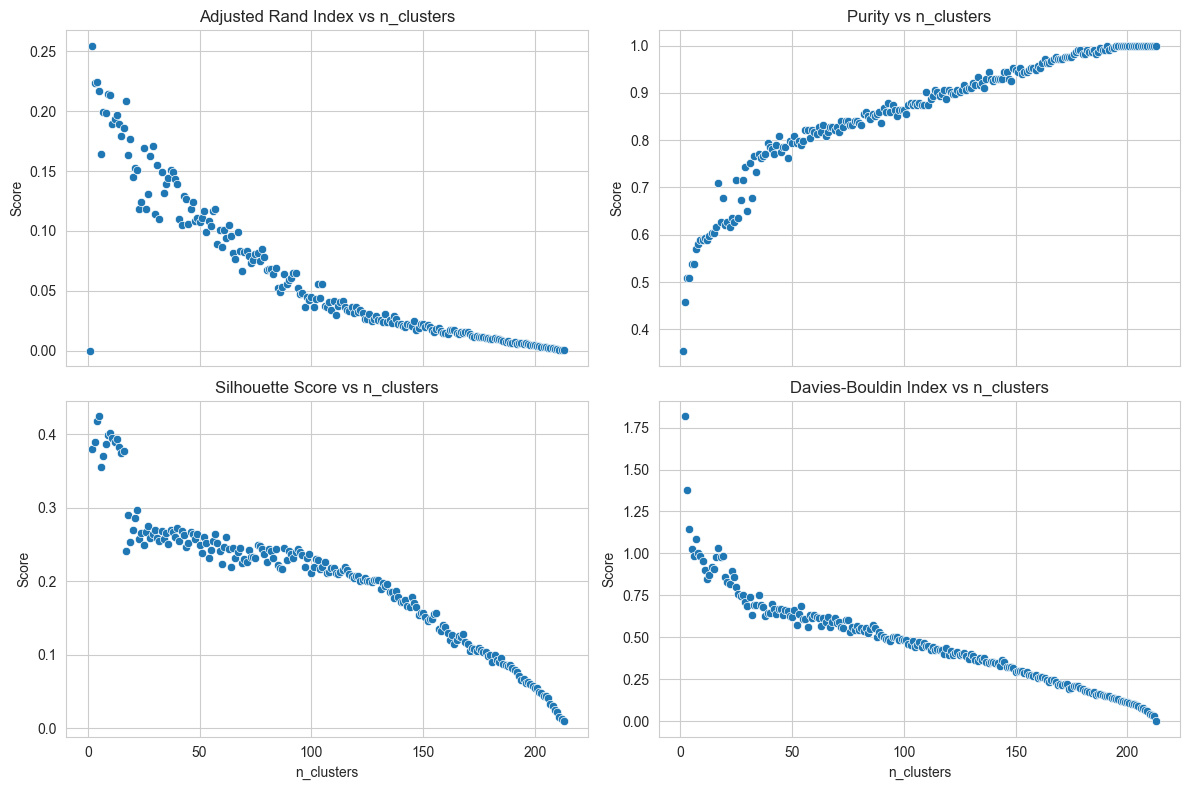

In [23]:
plot_metrics(metrics_glass_n_clusters, 'n_clusters')

In [24]:
metrics_glass_n_init = clustering_kmeans(
    X_glass,
    df_glass['Type_of_glass'],
    variable='n_init',
    min=2,
    max=300,
    step=1,
    n_clusters=6)

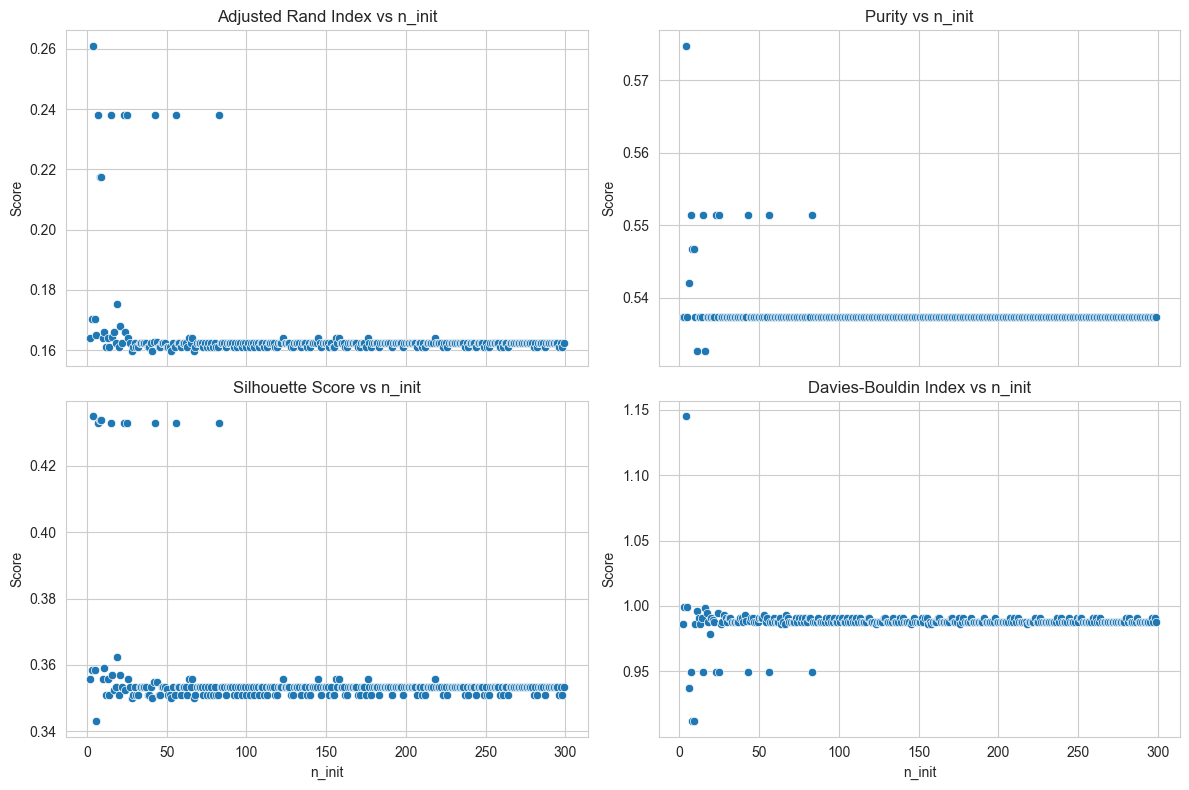

In [25]:
plot_metrics(metrics_glass_n_init, 'n_init')

In [26]:
metrics_glass_max_iter = clustering_kmeans(
    X_glass,
    df_glass['Type_of_glass'],
    variable='max_iter',
    min=10,
    max=500,
    step=10,
    n_clusters=6,
    n_init=10)

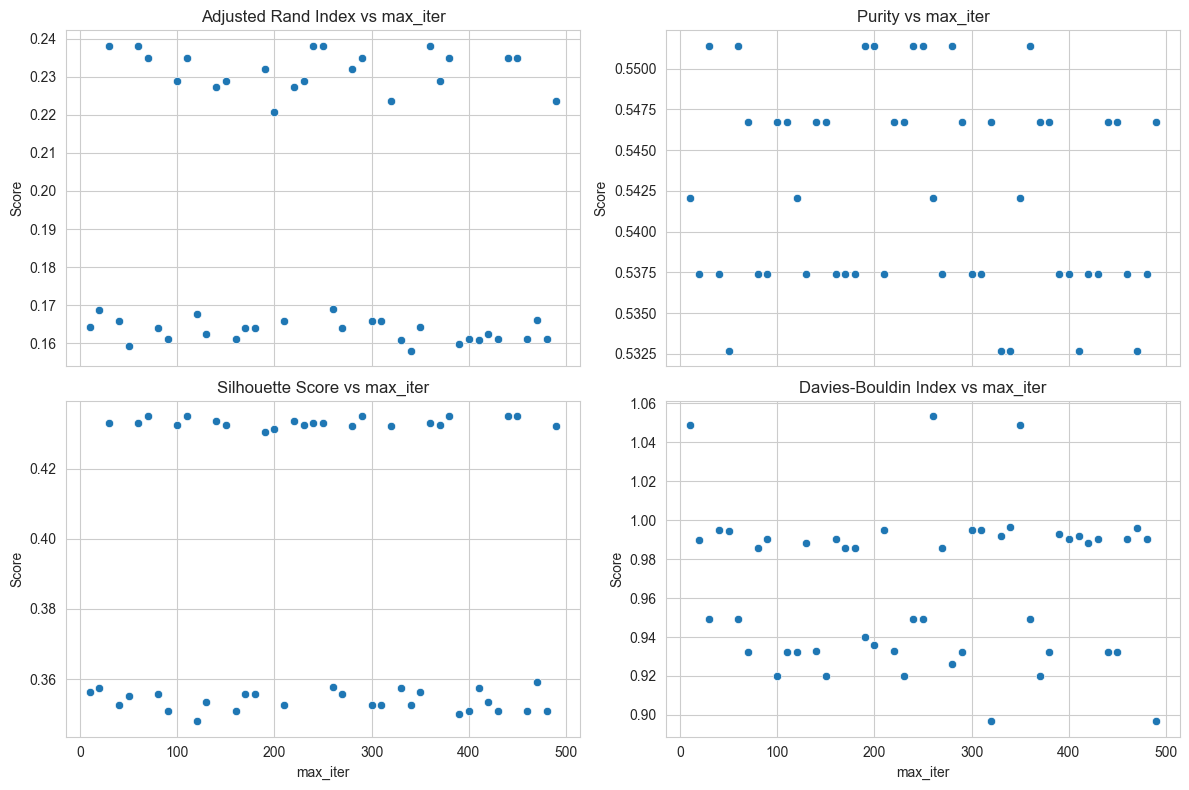

In [27]:
plot_metrics(metrics_glass_max_iter, 'max_iter')

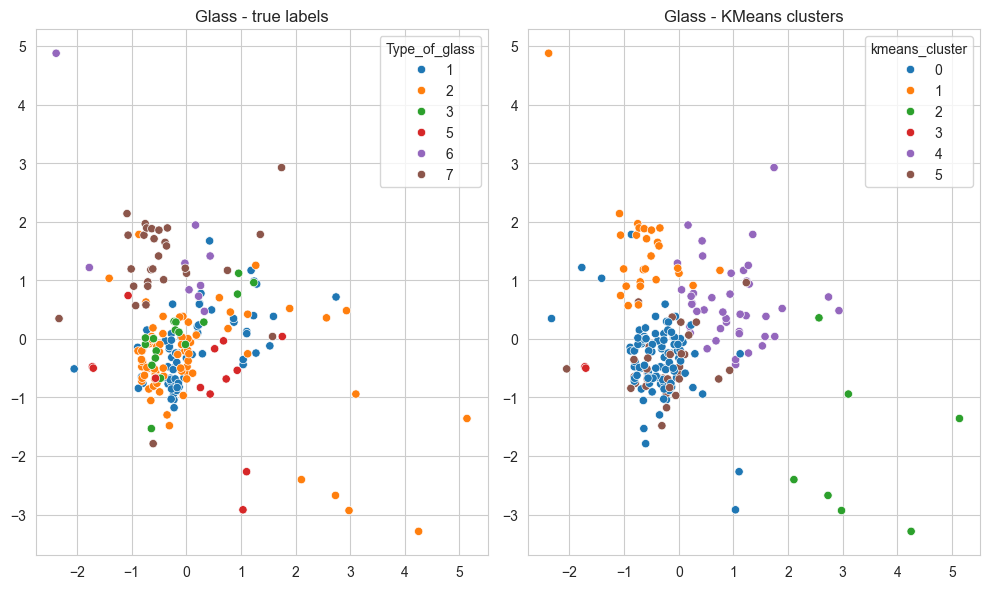

In [26]:
kmeans_glass = KMeans(n_clusters=6, n_init=10, max_iter=300)
kmeans_glass.fit_predict(X_glass)
df_glass['kmeans_cluster'] = kmeans_glass.labels_
fig, ax = plt.subplots(figsize=(10, 6), nrows=1, ncols=2)
sns.scatterplot(x=X_glass[:, 0], y=X_glass[:, 1], hue=df_glass['Type_of_glass'], ax=ax[0], palette='tab10')
sns.scatterplot(x=X_glass[:, 0], y=X_glass[:, 1], hue=df_glass['kmeans_cluster'], ax=ax[1], palette='tab10')
ax[0].set_title('Glass - true labels')
ax[1].set_title('Glass - KMeans clusters')
plt.tight_layout()
plt.show()

# DBSCAN

## Seeds

In [93]:
metrics_seeds_dbscan_eps = clustering_dbscan(
    X_seeds,
    seeds_df['class'],
    variable='eps',
    min_val=0.01,
    max_val=3,
    step=0.01)

metrics_seeds_dbscan_eps_manhatan = clustering_dbscan(
    X_seeds,
    seeds_df['class'],
    variable='eps',
    min_val=0.01,
    max_val=3,
    step=0.01,
    metrics_name='manhattan')

metrics_seeds_dbscan_eps_cosine = clustering_dbscan(
    X_seeds,
    seeds_df['class'],
    variable='eps',
    min_val=0.01,
    max_val=3,
    step=0.01,
    metrics_name='cosine')

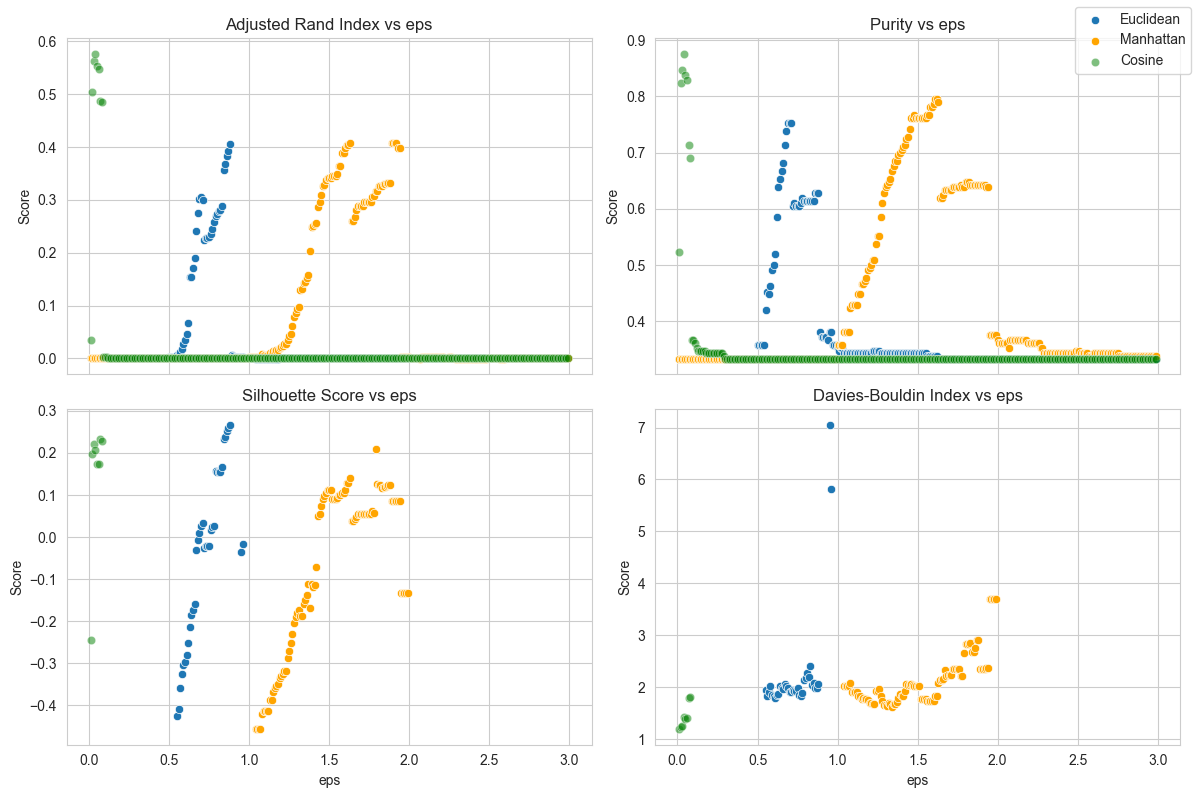

In [ ]:
# min samples 5
plot_metrics_dbscan(
    metrics_seeds_dbscan_eps,
    metrics_seeds_dbscan_eps_manhatan,
    metrics_seeds_dbscan_eps_cosine,
    'eps')

In [33]:
metrics_seeds_dbscan_eps2 = clustering_dbscan(
    X_seeds,
    seeds_df['class'],
    variable='eps',
    min_val=0.01,
    max_val=3,
    step=0.01,
    min_samples_value=50)

metrics_seeds_dbscan_eps_manhatan2 = clustering_dbscan(
    X_seeds,
    seeds_df['class'],
    variable='eps',
    min_val=0.01,
    max_val=3,
    step=0.01,
    metrics_name='manhattan',
    min_samples_value=50)

metrics_seeds_dbscan_eps_cosine2 = clustering_dbscan(
    X_seeds,
    seeds_df['class'],
    variable='eps',
    min_val=0.01,
    max_val=3,
    step=0.01,
    metrics_name='cosine',
    min_samples_value=50)

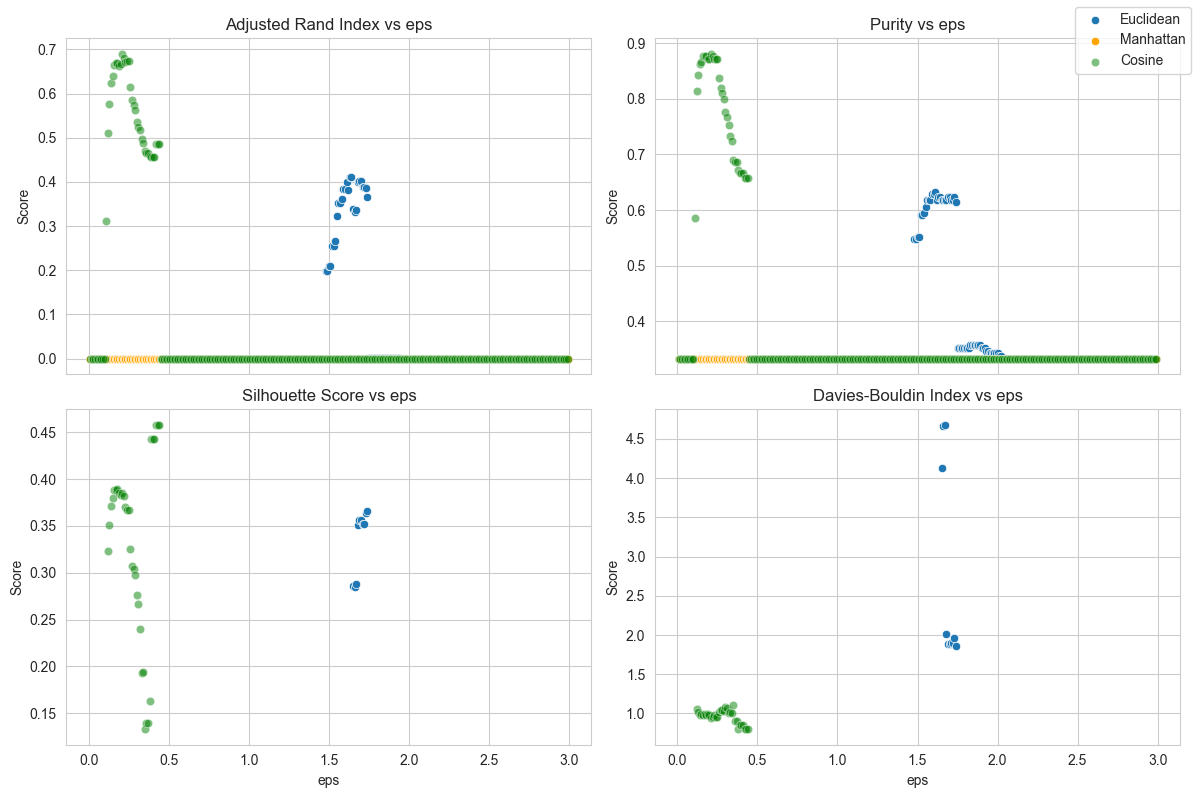

In [34]:
plot_metrics_dbscan(
    metrics_seeds_dbscan_eps2,
    metrics_seeds_dbscan_eps_manhatan2,
    metrics_seeds_dbscan_eps_cosine2,
    'eps')

In [110]:
metrics_seeds_dbscan_min_samples = clustering_dbscan(
    X_seeds,
    seeds_df['class'],
    variable='min_samples',
    min_val=2,
    max_val=210,
    step=1,
    eps_value=0.7)

metrics_seeds_dbscan_min_samples_manhatan = clustering_dbscan(
    X_seeds,
    seeds_df['class'],
    variable='min_samples',
    min_val=2,
    max_val=210,
    step=1,
    eps_value=0.7,
    metrics_name='manhattan')

metrics_seeds_dbscan_min_samples_cosine = clustering_dbscan(
    X_seeds,
    seeds_df['class'],
    variable='min_samples',
    min_val=2,
    max_val=210,
    step=1,
    eps_value=0.7,
    metrics_name='cosine')

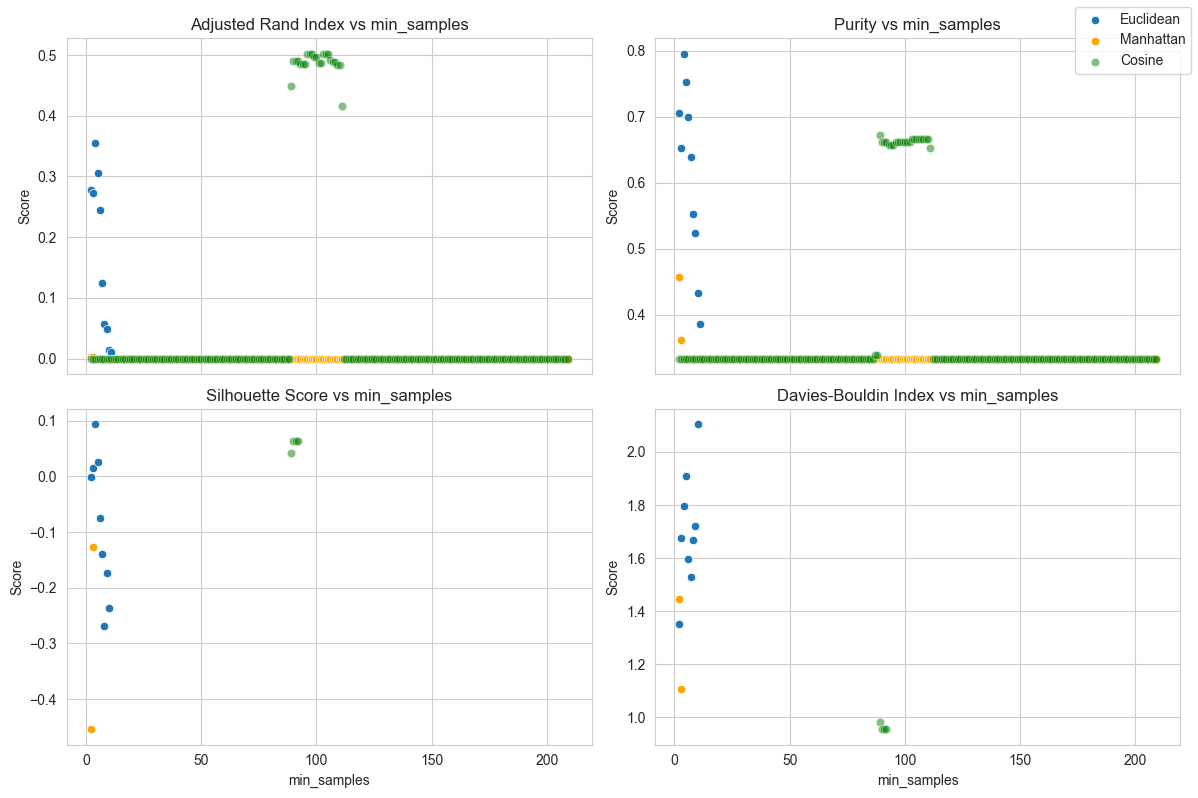

In [111]:
plot_metrics_dbscan(metrics_seeds_dbscan_min_samples,
                    metrics_seeds_dbscan_min_samples_manhatan,
                    metrics_seeds_dbscan_min_samples_cosine,
                    'min_samples')

In [37]:
metrics_seeds_dbscan_min_samples2 = clustering_dbscan(
    X_seeds,
    seeds_df['class'],
    variable='min_samples',
    min_val=2,
    max_val=210,
    step=1,
    eps_value=2)

metrics_seeds_dbscan_min_samples_manhatan2 = clustering_dbscan(
    X_seeds,
    seeds_df['class'],
    variable='min_samples',
    min_val=2,
    max_val=210,
    step=1,
    eps_value=2,
    metrics_name='manhattan')

metrics_seeds_dbscan_min_samples_cosine2 = clustering_dbscan(
    X_seeds,
    seeds_df['class'],
    variable='min_samples',
    min_val=2,
    max_val=210,
    step=1,
    eps_value=2,
    metrics_name='cosine')

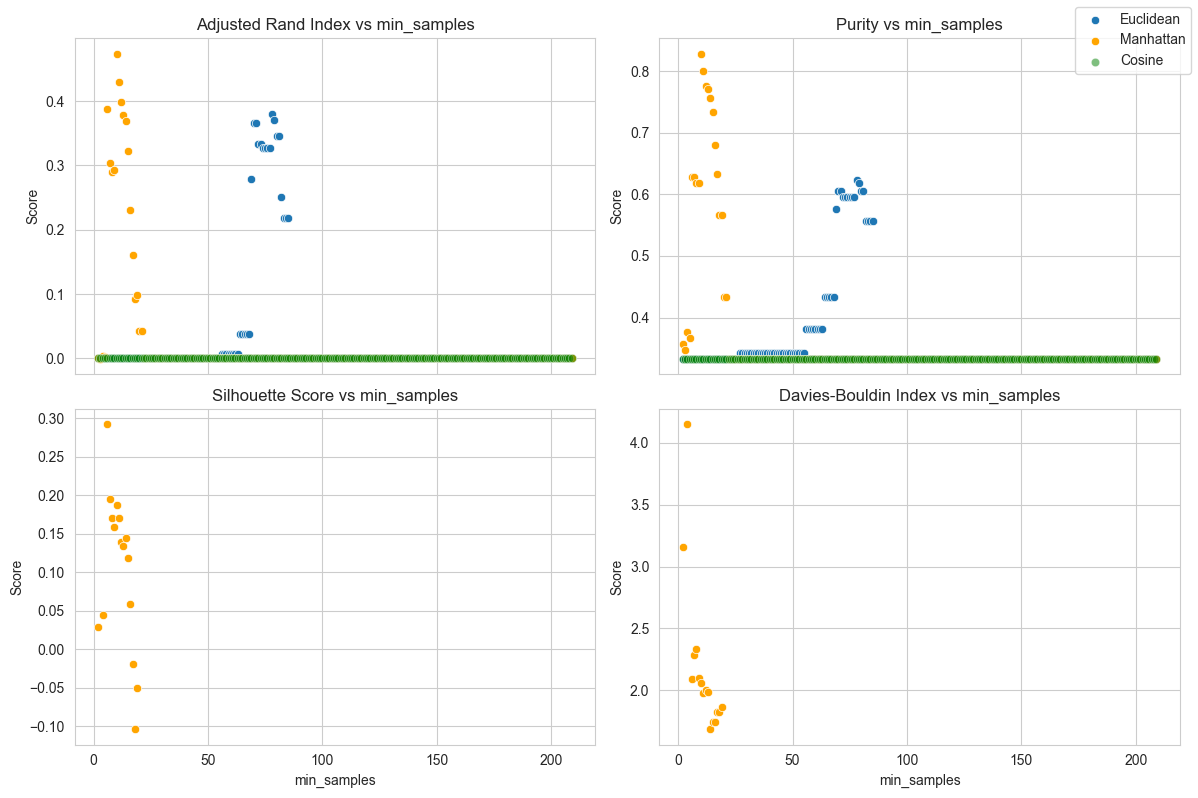

In [38]:
plot_metrics_dbscan(
    metrics_seeds_dbscan_min_samples2,
    metrics_seeds_dbscan_min_samples_manhatan2,
    metrics_seeds_dbscan_min_samples_cosine2,
    'min_samples')

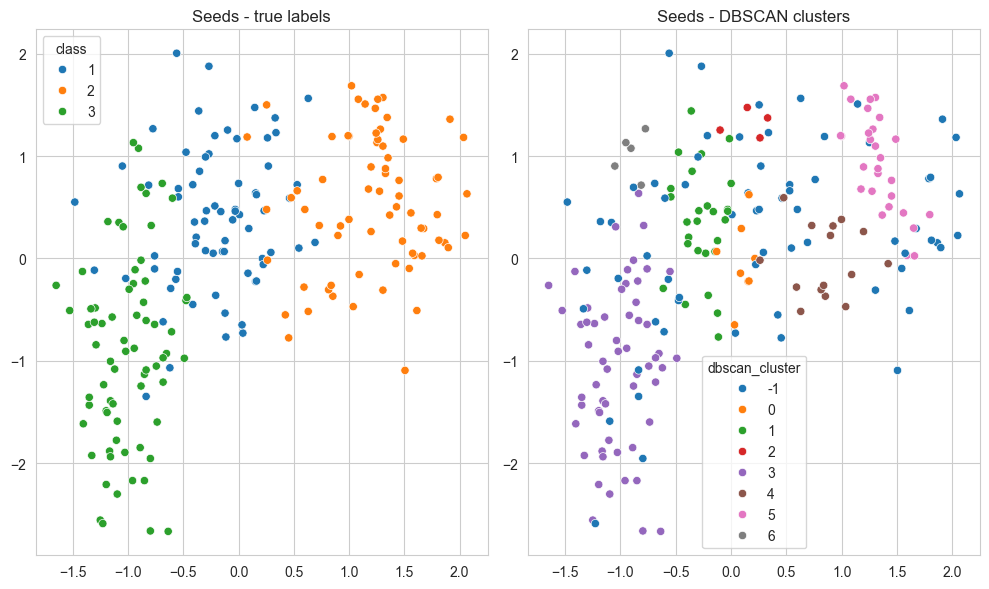

In [20]:
dbscan_seeds = DBSCAN(eps=0.7, min_samples=4, metric='euclidean').fit_predict(X_seeds)
seeds_df['dbscan_cluster'] = dbscan_seeds
fig, ax = plt.subplots(figsize=(10, 6), nrows=1, ncols=2)
sns.scatterplot(x=X_seeds[:, 1], y=X_seeds[:, 2], hue=seeds_df['class'], ax=ax[0], palette='tab10')
sns.scatterplot(x=X_seeds[:, 1], y=X_seeds[:, 2], hue=seeds_df['dbscan_cluster'], ax=ax[1], palette='tab10')
ax[0].set_title('Seeds - true labels')
ax[1].set_title('Seeds - DBSCAN clusters')
plt.tight_layout()
plt.show()

## Glass

In [114]:
metric_glass_dbscan_eps = clustering_dbscan(
    X_glass,
    df_glass['Type_of_glass'],
    variable='eps',
    min_val=0.1,
    max_val=4,
    step=0.01)

metric_glass_dbscan_eps_manhatan = clustering_dbscan(
    X_glass,
    df_glass['Type_of_glass'],
    variable='eps',
    min_val=0.1,
    max_val=4,
    step=0.01,
    metrics_name='manhattan')

metric_glass_dbscan_eps_cosine = clustering_dbscan(
    X_glass,
    df_glass['Type_of_glass'],
    variable='eps',
    min_val=0.1,
    max_val=4,
    step=0.01,
    metrics_name='cosine')

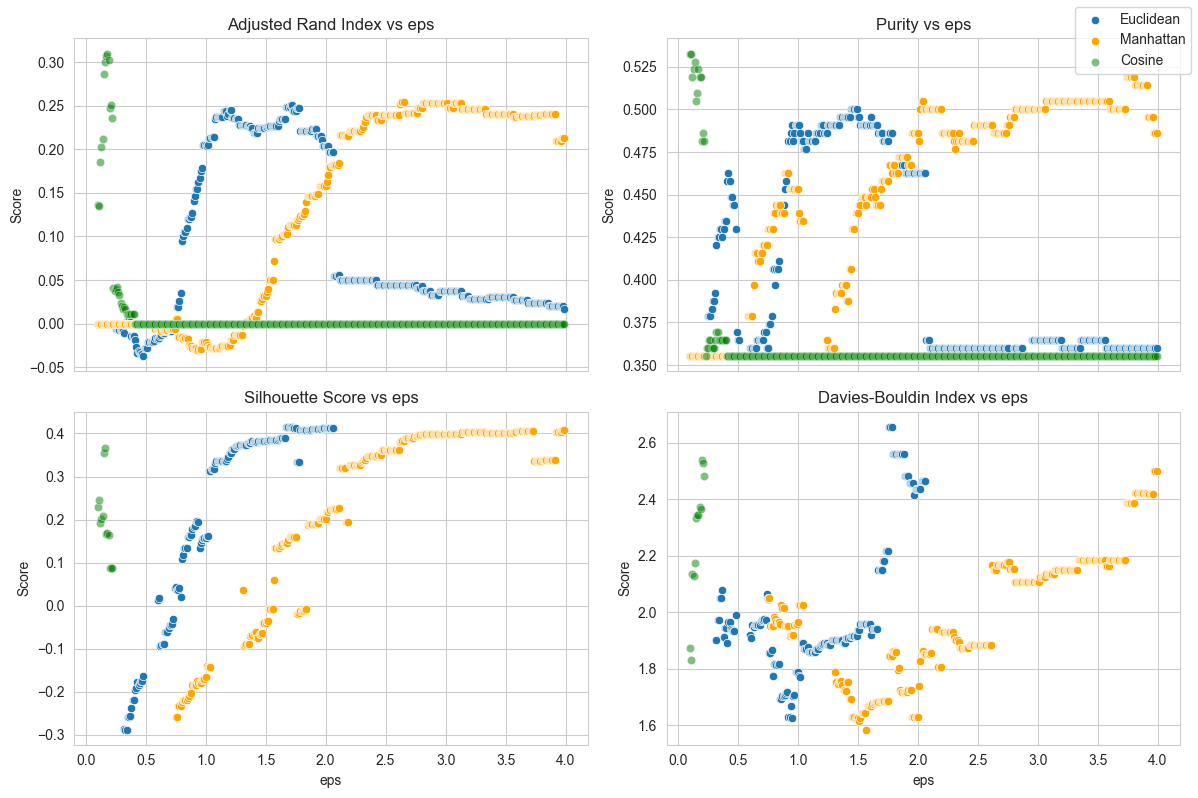

In [115]:
plot_metrics_dbscan(
    metric_glass_dbscan_eps,
    metric_glass_dbscan_eps_manhatan,
    metric_glass_dbscan_eps_cosine,
    'eps')

In [41]:
metric_glass_dbscan_eps2 = clustering_dbscan(
    X_glass,
    df_glass['Type_of_glass'],
    variable='eps',
    min_val=0.1,
    max_val=4,
    step=0.01,
    min_samples_value=25)

metric_glass_dbscan_eps_manhatan2 = clustering_dbscan(
    X_glass,
    df_glass['Type_of_glass'],
    variable='eps',
    min_val=0.1,
    max_val=4,
    step=0.01,
    metrics_name='manhattan',
    min_samples_value=25)

metric_glass_dbscan_eps_cosine2 = clustering_dbscan(
    X_glass,
    df_glass['Type_of_glass'],
    variable='eps',
    min_val=0.1,
    max_val=4,
    step=0.01,
    metrics_name='cosine',
    min_samples_value=25)

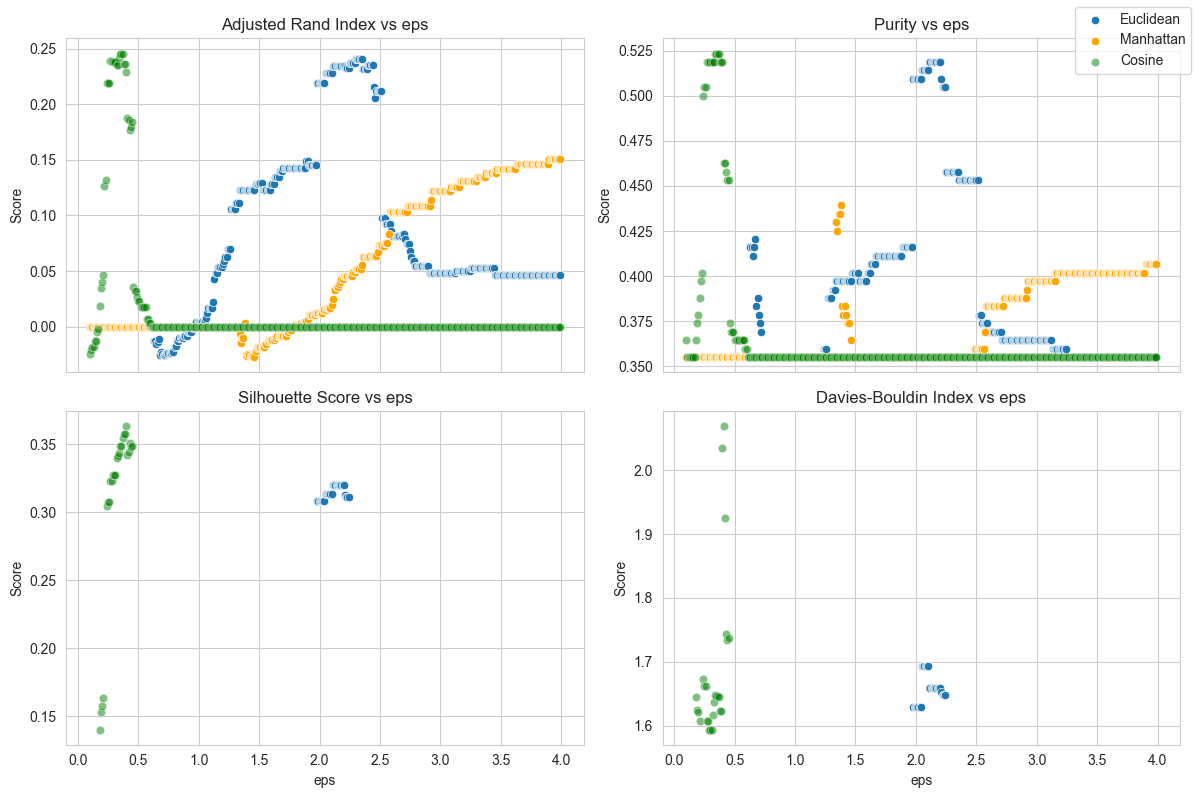

In [42]:
plot_metrics_dbscan(
    metric_glass_dbscan_eps2,
    metric_glass_dbscan_eps_manhatan2,
    metric_glass_dbscan_eps_cosine2,
    'eps'
)

In [116]:
metric_glass_dbscan_min_samples = clustering_dbscan(
    X_glass,
    df_glass['Type_of_glass'],
    variable='min_samples',
    min_val=2,
    max_val=214,
    step=1,
    eps_value=1.72)

metric_glass_dbscan_min_samples_manhatan = clustering_dbscan(
    X_glass,
    df_glass['Type_of_glass'],
    variable='min_samples',
    min_val=2,
    max_val=214,
    step=1,
    eps_value=1.72,
    metrics_name='manhattan')

metric_glass_dbscan_min_samples_cosine = clustering_dbscan(
    X_glass,
    df_glass['Type_of_glass'],
    variable='min_samples',
    min_val=2,
    max_val=214,
    step=1,
    eps_value=1.72,
    metrics_name='cosine')

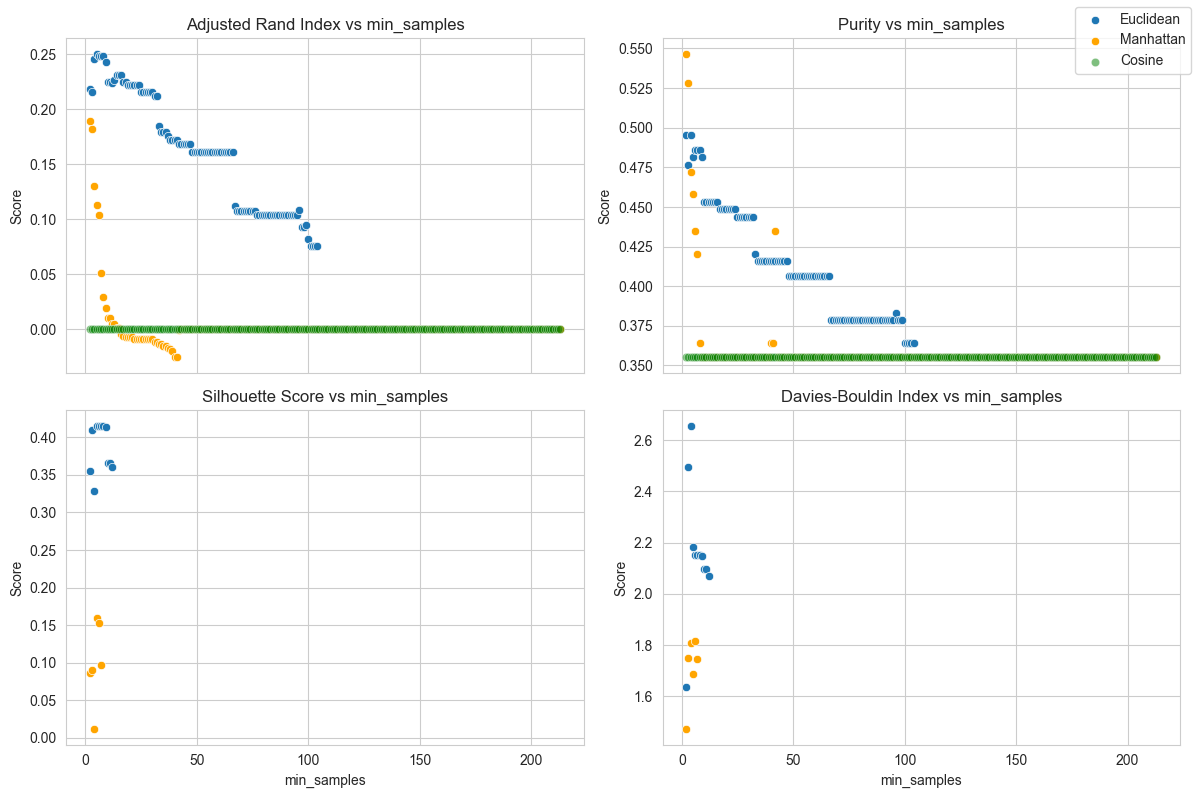

In [117]:
plot_metrics_dbscan(
    metric_glass_dbscan_min_samples,
    metric_glass_dbscan_min_samples_manhatan,
    metric_glass_dbscan_min_samples_cosine,
    'min_samples'
)

In [43]:
metric_glass_dbscan_min_samples2 = clustering_dbscan(
    X_glass,
    df_glass['Type_of_glass'],
    variable='min_samples',
    min_val=2,
    max_val=214,
    step=1,
    eps_value=0.5)

metric_glass_dbscan_min_samples_manhatan2 = clustering_dbscan(
    X_glass,
    df_glass['Type_of_glass'],
    variable='min_samples',
    min_val=2,
    max_val=214,
    step=1,
    eps_value=0.5,
    metrics_name='manhattan')

metric_glass_dbscan_min_samples_cosine2 = clustering_dbscan(
    X_glass,
    df_glass['Type_of_glass'],
    variable='min_samples',
    min_val=2,
    max_val=214,
    step=1,
    eps_value=0.5,
    metrics_name='cosine')

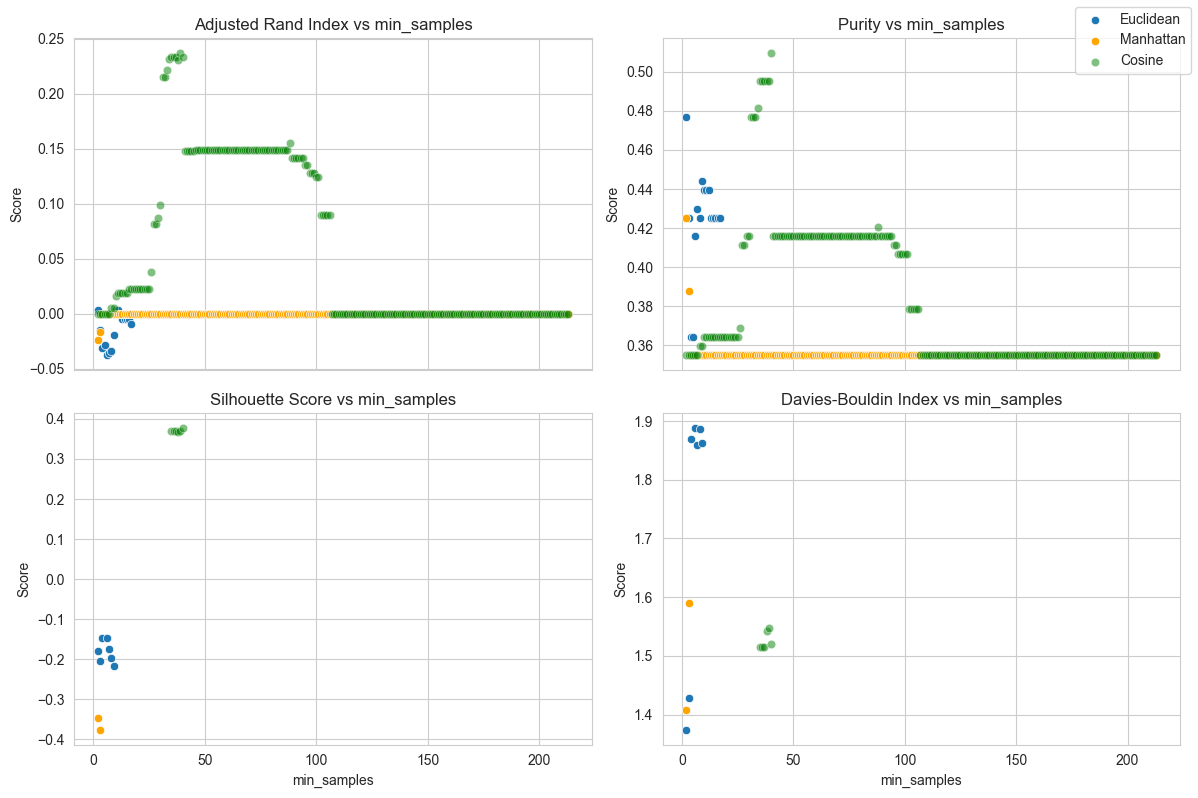

In [44]:
plot_metrics_dbscan(
    metric_glass_dbscan_min_samples2,
    metric_glass_dbscan_min_samples_manhatan2,
    metric_glass_dbscan_min_samples_cosine2,
    'min_samples'
)

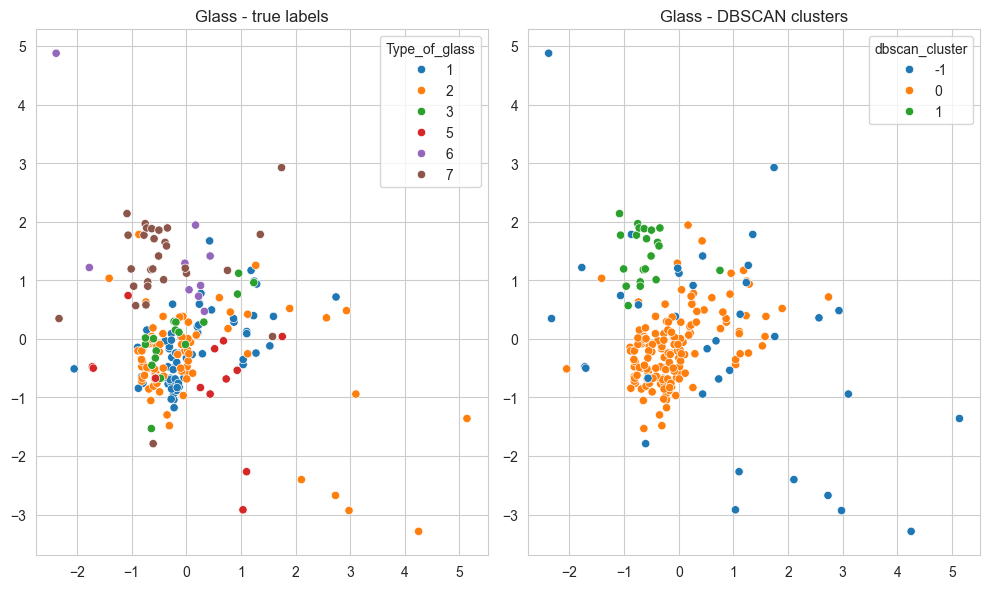

In [240]:
dbscan_glass = DBSCAN(eps=1.72, min_samples=5, metric='euclidean').fit_predict(X_glass)
df_glass['dbscan_cluster'] = dbscan_glass
fig, ax = plt.subplots(figsize=(10, 6), nrows=1, ncols=2)
sns.scatterplot(x=X_glass[:, 0], y=X_glass[:, 1], hue=df_glass['Type_of_glass'], ax=ax[0], palette='tab10')
sns.scatterplot(x=X_glass[:, 0], y=X_glass[:, 1], hue=df_glass['dbscan_cluster'], ax=ax[1], palette='tab10')
ax[0].set_title('Glass - true labels')
ax[1].set_title('Glass - DBSCAN clusters')
plt.tight_layout()
plt.show()

# Porównanie algorytmów

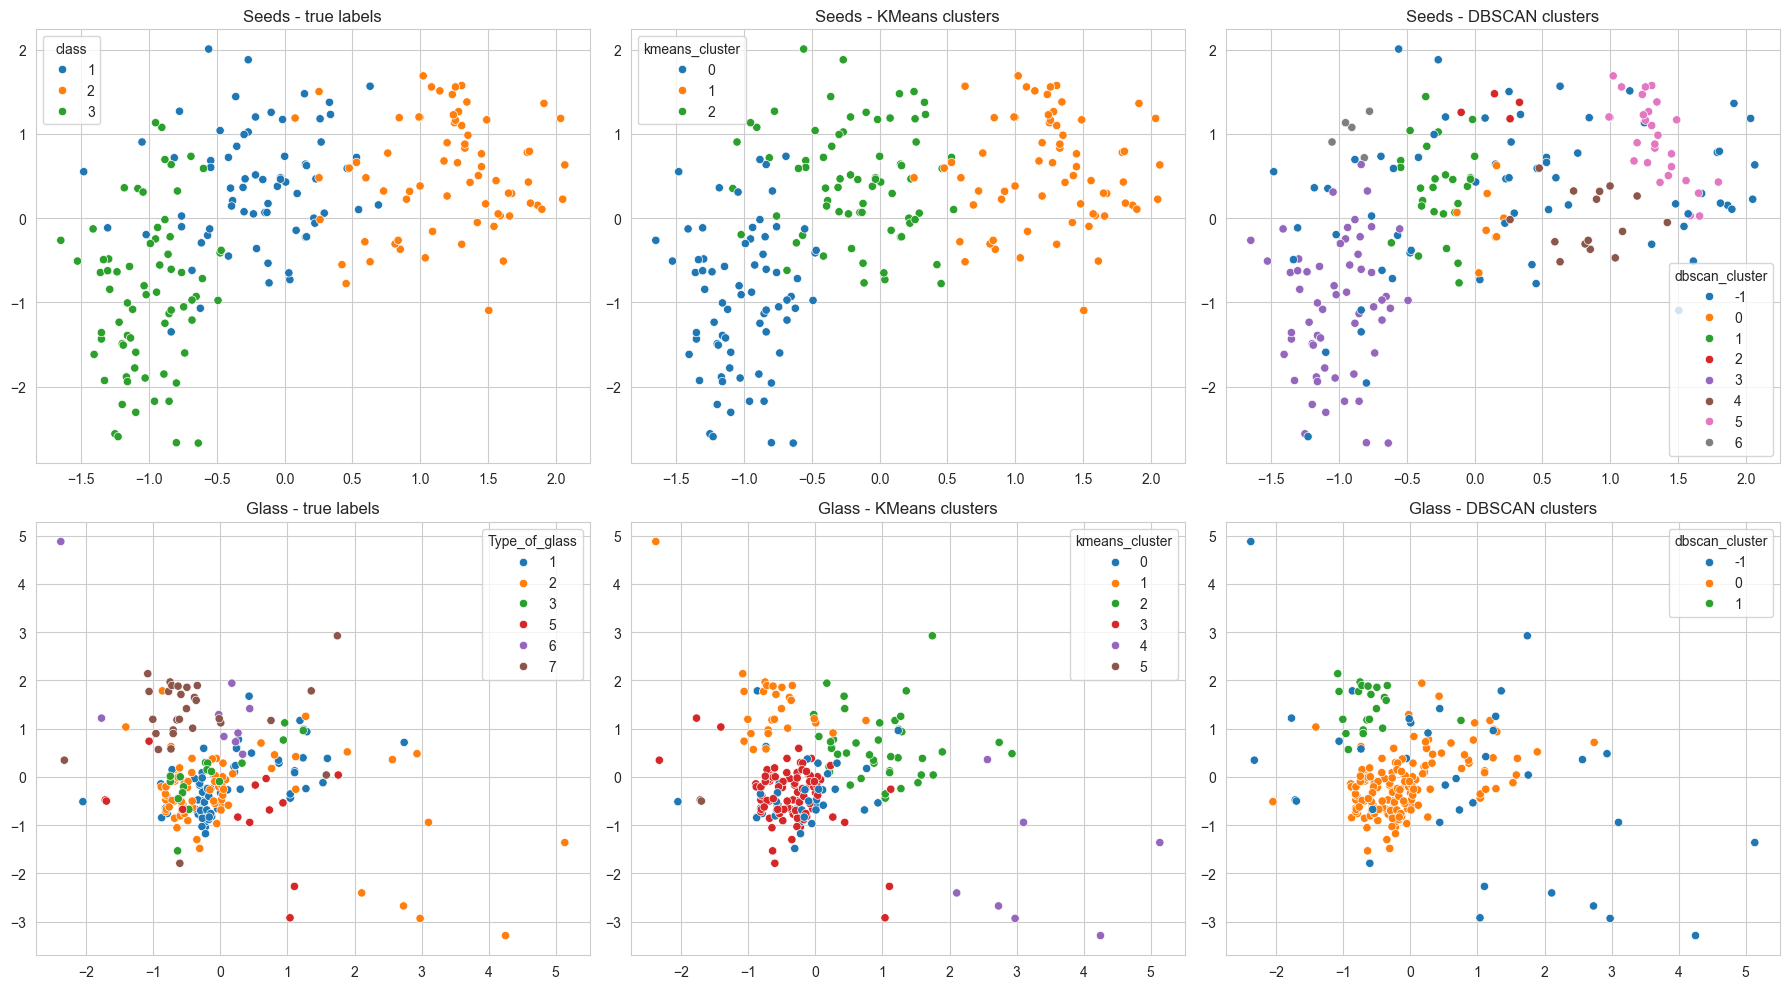

In [25]:
dbscan_seeds = DBSCAN(eps=0.7, min_samples=4, metric='euclidean').fit_predict(X_seeds)
kmeans_seeds = KMeans(n_clusters=3, n_init=10, max_iter=300, random_state=42)
kmeans_seeds_labels = kmeans_seeds.fit_predict(X_seeds)
seeds_df['kmeans_cluster'] = kmeans_seeds_labels
seeds_df['dbscan_cluster'] = dbscan_seeds

dbscan_glass = DBSCAN(eps=1.72, min_samples=5, metric='euclidean').fit_predict(X_glass)
kmeans_glass = KMeans(n_clusters=6, n_init=10, max_iter=300, random_state=42)
kmeans_glass_labels = kmeans_glass.fit_predict(X_glass)
df_glass['kmeans_cluster'] = kmeans_glass_labels
df_glass['dbscan_cluster'] = dbscan_glass

fig, ax = plt.subplots(figsize=(18, 10), nrows=2, ncols=3)
sns.scatterplot(x=X_seeds[:, 1], y=X_seeds[:, 2], hue=seeds_df['class'], ax=ax[0, 0], palette='tab10')
ax[0, 0].set_title('Seeds - true labels')
sns.scatterplot(x=X_seeds[:, 1], y=X_seeds[:, 2], hue=seeds_df['kmeans_cluster'], ax=ax[0, 1], palette='tab10')
ax[0, 1].set_title('Seeds - KMeans clusters')
sns.scatterplot(x=X_seeds[:, 1], y=X_seeds[:, 2], hue=seeds_df['dbscan_cluster'], ax=ax[0, 2], palette='tab10')
ax[0, 2].set_title('Seeds - DBSCAN clusters')
sns.scatterplot(x=X_glass[:, 0], y=X_glass[:, 1], hue=df_glass['Type_of_glass'], ax=ax[1, 0], palette='tab10')
ax[1, 0].set_title('Glass - true labels')
sns.scatterplot(x=X_glass[:, 0], y=X_glass[:, 1], hue=df_glass['kmeans_cluster'], ax=ax[1, 1], palette='tab10')
ax[1, 1].set_title('Glass - KMeans clusters')
sns.scatterplot(x=X_glass[:, 0], y=X_glass[:, 1], hue=df_glass['dbscan_cluster'], ax=ax[1, 2], palette='tab10')
ax[1, 2].set_title('Glass - DBSCAN clusters')
plt.tight_layout()
plt.show()

# Jak działają algorytmy?

**KMeans**

1. Wybierz liczbę klastrów k.

2. Losowo zainicjalizuj k centroidów (środków klastrów).

3. Przypisz każdy punkt do najbliższego centroidu (np. wg odległości euklidesowej).

4. Oblicz nowe centroidy jako średnie wszystkich punktów przypisanych do danego klastra.

5. Powtarzaj kroki 3–4, aż:
- centroidy się nie zmieniają (konwergencja),
- osiągnięto maksymalną liczbę iteracji (max_iter).

**DBScan**

`eps` - promień otoczenia danego punktu, określa jak blisko muszą być inne punkty, by były uznane za sąsiadów
`min_samples` - minimalna liczba punktów w otoczeniu, aby uznać je za gęsty obszar

1. Dla każdego punktu:
- policz, ile punktów znajduje się w promieniu eps.
- jeśli więcej niż (lub równo) min_samples, to punkt staje się rdzeniowy (core).

Twórz klaster wokół punktu rdzeniowego, łącząc sąsiadujące punkty.

Punkty, które nie należą do żadnego klastra i nie są rdzeniowe, są oznaczane jako szum (noise).

# Pytania pomocnicze
**1. Czy przy grupowaniu potrzebna jest normalizacja/standaryzacja danych?**

- Tak jest potrzebna. Algorytmy k-means i DBSCAN opierają się na metrykach odległości (np. euklidesowej), więc różne skale cech mogą zniekształcić wyniki. Standaryzacja pozwala porównać cechy o różnych zakresach.

**2. Co różni oba algorytmy z punktu widzenia reprezentacji klastra? Jaką konsekwencję mają te różnice na możliwości wykonywania „predykcji”?**

- k-means: reprezentuje klaster przez centroid – średni punkt danych w klastrze. Pozwala na przypisanie nowych punktów do najbliższego centroidu, więc umożliwia predykcję.
- DBSCAN: nie tworzy centroidów – klastry definiowane są przez punkty rdzeniowe i ich sąsiedztwo. Nie nadaje się bezpośrednio do predykcji nowych punktów, ponieważ nie ma prostego mechanizmu przypisania.

**3. Który z algorytmów jest mniej odporny na szum i wartości odstające (ang. outliers)? Dlaczego?**

- k-means jest mniej odporny na outliery, ponieważ minimalizuje średni błąd kwadratowy, a outliery mogą mocno przesunąć centroidy.
- DBSCAN jest bardziej odporny, bo traktuje punkty niepasujące do gęstych skupisk jako szum i ich nie przypisuje do żadnego klastra.

**4. Czy w zadaniu grupowania powinniśmy użyć walidacji krzyżowej?**

- Nie, mamy inne metryki oceny jakości klastrów, takie jak silhouette score czy Davies-Bouldin index. Walidacja krzyżowa jest bardziej odpowiednia dla algorytmów klasyfikacji i regresji.

**5. Czy wyniki badanych algorytmów klasteryzacji powinny być powtarzane i uśredniane?**

- Tak dla k-means. Ze względu na losową inicjalizację centroidów, warto uruchomić algorytm wielokrotnie (parametr n_init) i analizować średnie wyniki metryk. Dla DBSCAN powtarzanie ma mniejszy sens (nie zawiera losowości, ale może być czuły na małe zmiany danych).

**6. Co mierzą miary klasteryzacji podane w treści zdania?**

- Unsupervised:

(a) Silhouette: jak dobrze punkt pasuje do swojego klastra vs. innych klastrów. Od -1 do 1. 1 - dobrze dopasowany, 0 - na granicy klastrów, -1 punkt został przypisany do niewłaściwego klastra.

(b) Davies-Bouldin Index: relacja między rozrzutem klastrów a ich oddzieleniem – im niższy, tym lepiej. Zakres od 0 do $\infty$, gdzie 0 oznacza idealne klastry (brak rozrzutu i maksymalne oddzielenie).

- Supervised:

(a) Rand Index: zgodność par punktów (czy są razem/oddzielnie w klastrach i klasach), od 0 (brak zgodności) do 1 (pełna zgodność).

(b) Purity: udział dominującej klasy w klastrze – im wyższy, tym lepiej, od 0 (klastry kompletnie losowe względem klas) do 1 (klastry czyste, wszystkie punkty w klastrze należą do tej samej klasy).

**7. Czy konieczne jest ustawianie liczby klastrów tak, by odpowiadała liczbie klas?**

Nie. Liczba klas i klastrów nie musi być taka sama. Klasteryzacja może wykrywać strukturę danych niezależnie od klas. W niektórych przypadkach lepiej oddaje naturalne skupiska, nawet jeśli liczba klastrów się różni.
